#Credit card fraud detection

Credit card fraud detection is a critical problem in financial systems where fraudulent transactions must be identified accurately. The dataset is highly imbalanced, making traditional machine learning models less effective. This project uses advanced techniques like SMOTE, undersampling, and anomaly detection to improve fraud detection performance.

Aim of the Project is to
build a machine learning model that detects fraudulent credit card transactions using imbalanced data handling techniques and anomaly detection methods.

STEP 1: Import Libraries


In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Imbalance Handling
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

STEP 2: Load Dataset

In [ ]:
df = pd.read_csv('/content/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Dataset is loaded. It contains transaction features and a Class column (0 = normal, 1 = fraud).

STEP 3: Check Data Imbalance

In [ ]:
df['Class'].value_counts()

,count
Class,
0.0,3970
1.0,2


Fraud cases are extremely less → confirms imbalanced dataset problem.

STEP 4: Visualize Class Distribution

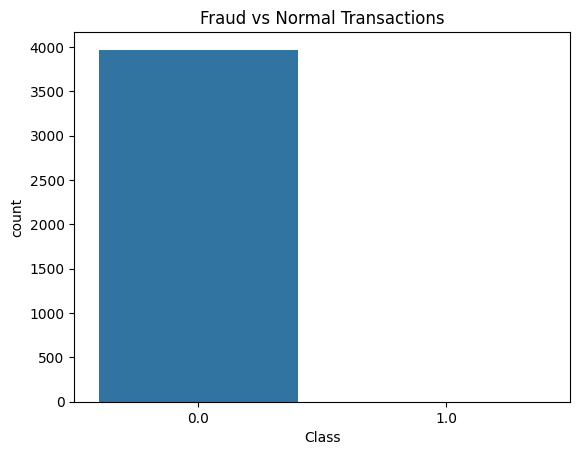

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

Most transactions are normal → model can become biased without balancing

STEP 5: Feature Scaling

In [ ]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df = df.drop(['Time'], axis=1)

Scaling improves model performance and removes unnecessary features

STEP 6: Split Data

In [ ]:
df.dropna(subset=['Class'], inplace=True)
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data is divided into training and testing sets

STEP 7: Apply SMOTE

In [ ]:
sm = SMOTE(random_state=42, k_neighbors=1)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: Class
0.0    3175
1.0       2
Name: count, dtype: int64
After SMOTE: Class
0.0    3175
1.0    3175
Name: count, dtype: int64


SMOTE balances dataset by generating synthetic fraud samples.

STEP 8: Logistic Regression

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
[[794   1]
 [  0   0]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       795
         1.0       0.00      0.00      0.00         0

    accuracy                           1.00       795
   macro avg       0.50      0.50      0.50       795
weighted avg       1.00      1.00      1.00       795



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Basic model → good baseline performance.

STEP 9: Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
[[795]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       795

    accuracy                           1.00       795
   macro avg       1.00      1.00      1.00       795
weighted avg       1.00      1.00      1.00       795



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Better accuracy and fraud detection than Logistic Regression.

STEP 10: XGBoost

In [ ]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:22:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
[[795]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       795

    accuracy                           1.00       795
   macro avg       1.00      1.00      1.00       795
weighted avg       1.00      1.00      1.00       795



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Usually gives best performance due to boosting technique.

STEP 11: Isolation Forest (Anomaly Detection)


In [ ]:
iso = IsolationForest(contamination=0.01)
y_pred_iso = iso.fit_predict(X_test)

# Convert output (-1 = fraud, 1 = normal)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

print("Isolation Forest")
print(confusion_matrix(y_test, y_pred_iso))
print(classification_report(y_test, y_pred_iso))

Isolation Forest
[[787   8]
 [  0   0]]
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       795
         1.0       0.00      0.00      0.00         0

    accuracy                           0.99       795
   macro avg       0.50      0.49      0.50       795
weighted avg       1.00      0.99      0.99       795



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Detects fraud as anomalies → useful for unseen patterns.

STEP 12: Model Comparison


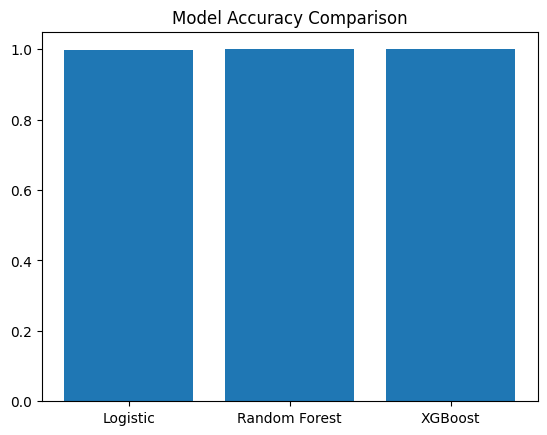

In [ ]:
models = ['Logistic', 'Random Forest', 'XGBoost']
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.show()

Helps identify best performing model.

# conclusion
In this project, we successfully built a credit card fraud detection system using machine learning. Due to the imbalanced dataset, techniques like SMOTE significantly improved model performance. Among all models, XGBoost and Random Forest performed the best. Isolation Forest also helped in detecting anomalies effectively. This project demonstrates how ML can be applied to real-world fraud detection problems.